# GeoTIFF to PNG visualization

This notebook reads an xBD GeoTIFF with `tifffile`, converts it to an 8-bit RGB image for display, and previews the result directly in Jupyter.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile


def ensure_hwc(image: np.ndarray) -> np.ndarray:
    """Convert a channel-first array to HWC when needed."""
    image = np.asarray(image)
    if image.ndim == 3 and image.shape[0] in {1, 3, 4} and image.shape[-1] not in {1, 3, 4}:
        image = np.moveaxis(image, 0, -1)
    return image


def to_uint8_for_display(image: np.ndarray, stretch_percentiles=(2, 98)) -> np.ndarray:
    """Convert TIFF pixel values to uint8 for visualization."""
    image = ensure_hwc(image).astype(np.float32)

    if image.ndim == 2:
        image = image[..., None]

    if image.min() >= 0 and image.max() <= 255:
        display = np.clip(image, 0, 255).astype(np.uint8)
        return display[..., 0] if display.shape[-1] == 1 else display

    low_q, high_q = stretch_percentiles
    display = np.empty_like(image, dtype=np.uint8)

    for channel_idx in range(image.shape[-1]):
        channel = image[..., channel_idx]
        lo, hi = np.percentile(channel, [low_q, high_q])

        if hi <= lo:
            lo = float(channel.min())
            hi = float(channel.max())

        if hi <= lo:
            scaled = np.zeros_like(channel, dtype=np.uint8)
        else:
            clipped = np.clip(channel, lo, hi)
            scaled = ((clipped - lo) / (hi - lo) * 255.0).astype(np.uint8)

        display[..., channel_idx] = scaled

    return display[..., 0] if display.shape[-1] == 1 else display


def load_geotiff_for_display(tif_path: Path, stretch_percentiles=(2, 98)):
    tif_path = Path(tif_path)
    image = tifffile.imread(tif_path)
    display = to_uint8_for_display(image, stretch_percentiles=stretch_percentiles)
    return image, display


TIFF path: D:\products\bishe\disaster-retrieval-system\disaster-retrieval-system\data\raw\xbd\geotiffs\hold\images\guatemala-volcano_00000004_post_disaster.tif
Raw shape: (1024, 1024, 3), dtype: int16, min: 2, max: 255
Display shape: (1024, 1024, 3), dtype: uint8


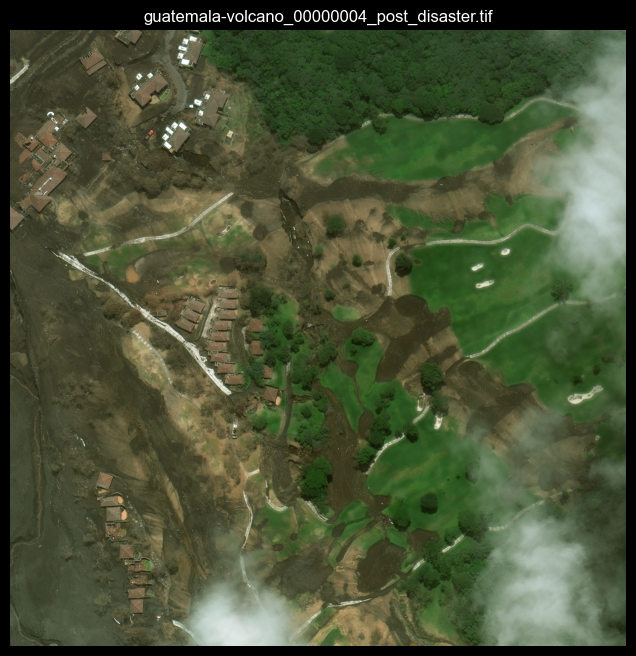

In [5]:
tif_path = Path(
    r"/disaster-retrieval-system/data/raw/xbd/geotiffs/hold/images/guatemala-volcano_00000004_post_disaster.tif")
raw_image, display_image = load_geotiff_for_display(tif_path)

print(f"TIFF path: {tif_path}")
print(f"Raw shape: {raw_image.shape}, dtype: {raw_image.dtype}, min: {raw_image.min()}, max: {raw_image.max()}")
print(f"Display shape: {display_image.shape}, dtype: {display_image.dtype}")

plt.figure(figsize=(8, 8))
plt.imshow(display_image)
plt.title(tif_path.name)
plt.axis("off")
plt.show()


TIFF path: D:\products\bishe\disaster-retrieval-system\disaster-retrieval-system\data\raw\xbd\geotiffs\hold\images\guatemala-volcano_00000004_pre_disaster.tif
Raw shape: (1024, 1024, 3), dtype: int16, min: 1, max: 255
Display shape: (1024, 1024, 3), dtype: uint8


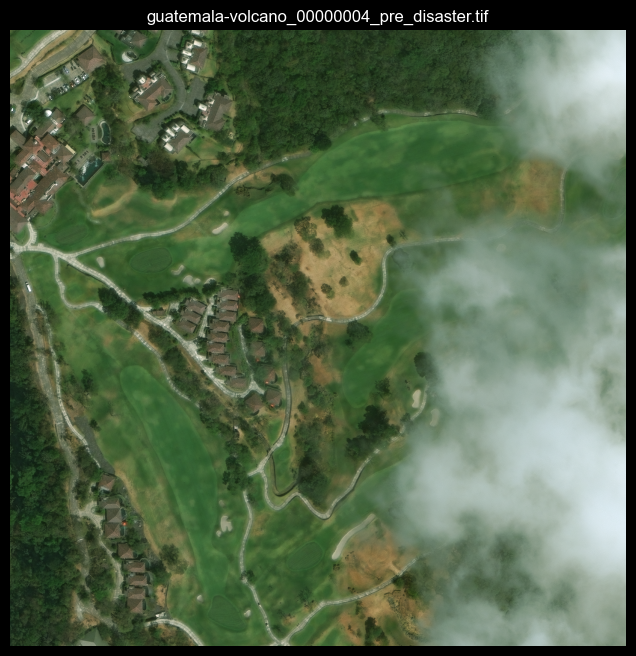

In [6]:
tif_path = Path(
    r"/disaster-retrieval-system/data/raw/xbd/geotiffs/hold/images/guatemala-volcano_00000004_pre_disaster.tif")
raw_image, display_image = load_geotiff_for_display(tif_path)

print(f"TIFF path: {tif_path}")
print(f"Raw shape: {raw_image.shape}, dtype: {raw_image.dtype}, min: {raw_image.min()}, max: {raw_image.max()}")
print(f"Display shape: {display_image.shape}, dtype: {display_image.dtype}")

plt.figure(figsize=(8, 8))
plt.imshow(display_image)
plt.title(tif_path.name)
plt.axis("off")
plt.show()


In [4]:
import tifffile
import numpy as np

path = "disaster/data/raw/xbd/geotiffs/hold/images/santa-rosa-wildfire_00000008_pre_disaster.tif"
img = tifffile.imread(path)

print("shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())

if img.ndim == 2:
    print("﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ TIF")
elif img.ndim == 3:
    print("﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ TIF﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿:", img.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/root/autodl-tmp/dfr/disaster/data/raw/xbd/geotiffs/hold/images/santa-rosa-wildfire_00000008_pre_disaster.tif'